In [1]:
import numpy as np
from torch import nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader

from models import TabularAutoencoder
from utils import TabularMissingness
from utils import get_device
from utils import get_tabular_data
from utils import load_penguins, load_iris, load_gaussian
from utils import plot_latent_space, plot_reconstruction_comparison
from utils import train_tabular_autoencoder
from torch.nn import KLDivLoss
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from utils import clustering_accuracy, plot_latent_space

from models import DEC
import torch
from utils import train_dec

In [2]:
missingness = TabularMissingness()

device = get_device()

# Load the data

In [3]:
# X, y, classes = load_penguins(return_numpy=True, encode_labels=True)
# tensor_x, y_true, data_indices, classes = get_tabular_data('penguins', device=device)


# X, y, classes = load_iris(return_numpy=True, encode_labels=True)
# tensor_x, y_true, data_indices, classes = get_tabular_data('iris', device=device)


X, y, classes = load_gaussian(
    n_samples=1500,
    n_features=4,
    centers=3,
    cluster_std=0.8,
    random_state=40
)

tensor_x, y_true, data_indices, classes = get_tabular_data(
    "gaussian",
    device=device,
    n_samples=1500,
    n_features=4,
    centers=3,
    cluster_std=0.8,
    random_state=40
)

dataset = TensorDataset(tensor_x, data_indices)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Autoencoder

In [7]:
ae = TabularAutoencoder(
    input_dim=X.shape[1],
    latent_dim=2
).to(device)
ae_optimizer = optim.Adam(ae.parameters(), lr=1e-3)
ae_loss_fn = nn.MSELoss()

In [8]:
ae_losses = train_tabular_autoencoder(
    model=ae,
    train_loader=loader,
    loss_fn=ae_loss_fn,
    optimizer=ae_optimizer,
    epochs=100,
    device=device,
)

AE Epoch 050/100: Loss = 0.032742
AE Epoch 100/100: Loss = 0.018484


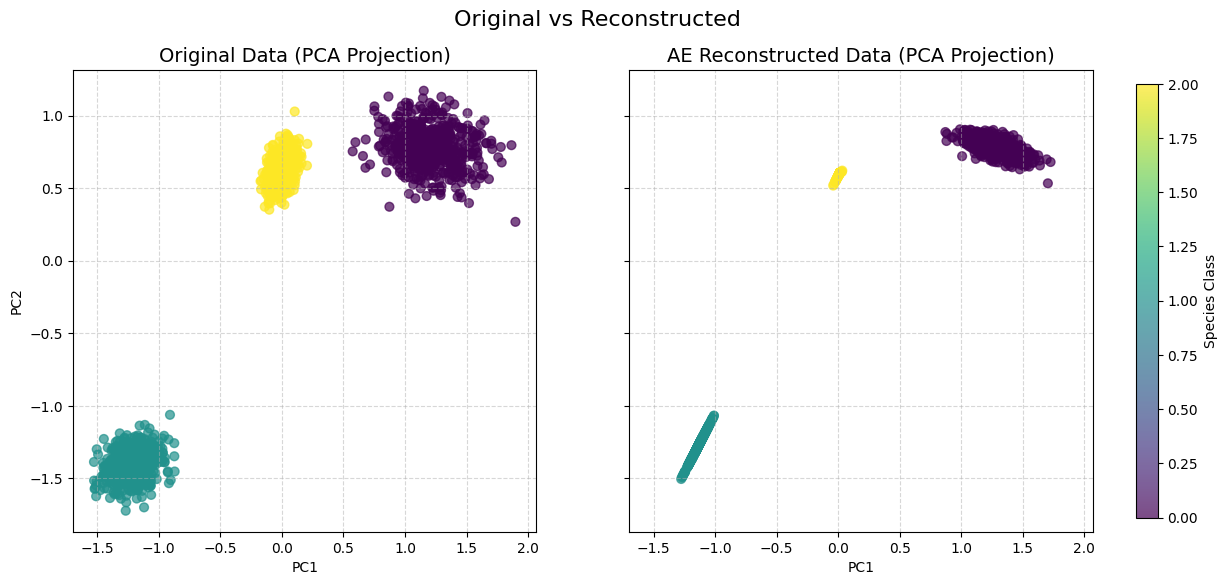

In [9]:
plot_reconstruction_comparison(ae, tensor_x, y, device=device)

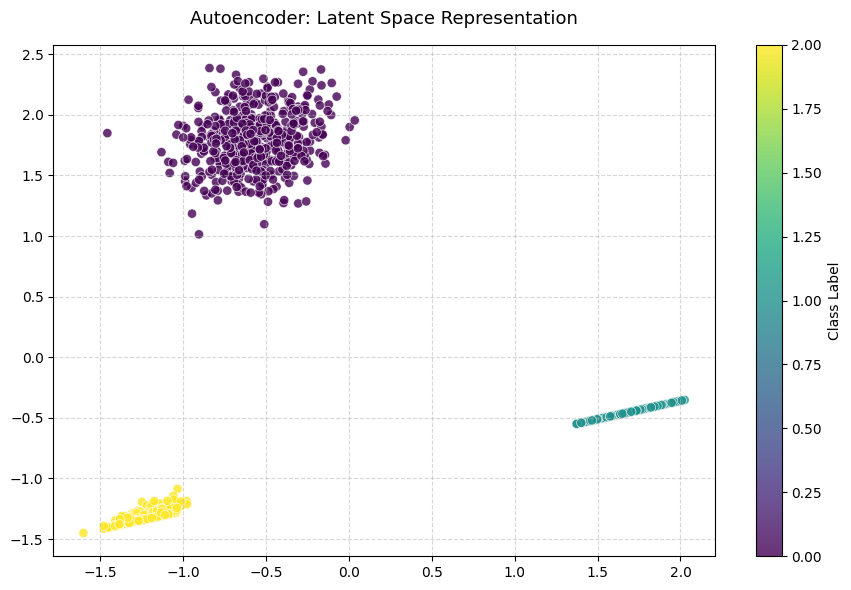

In [10]:
plot_latent_space(ae, tensor_x, y, device=device)

# Denoising Autoencoder

In [ ]:
missing_x = missingness.apply_stratified(
    X, y, method="mcar", frac=0.25
)

tensor_x_missing = torch.from_numpy(missing_x).float().to(device)


dae_dataset = TensorDataset(tensor_x_missing, data_indices)
dae_loader = DataLoader(dae_dataset, batch_size=32, shuffle=True)

In [29]:
dae = TabularAutoencoder(input_dim=X.shape[1], latent_dim=2).to(device)
optimizer = optim.Adam(dae.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

corruption_kwargs = {
    'method': 'mcar',
    'frac': 0,
}

In [30]:
losses = train_tabular_autoencoder(
    model=dae,
    train_loader=loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    epochs=100,
    device=device,
)

AE Epoch 050/100: Loss = 0.779203
AE Epoch 100/100: Loss = 0.526616


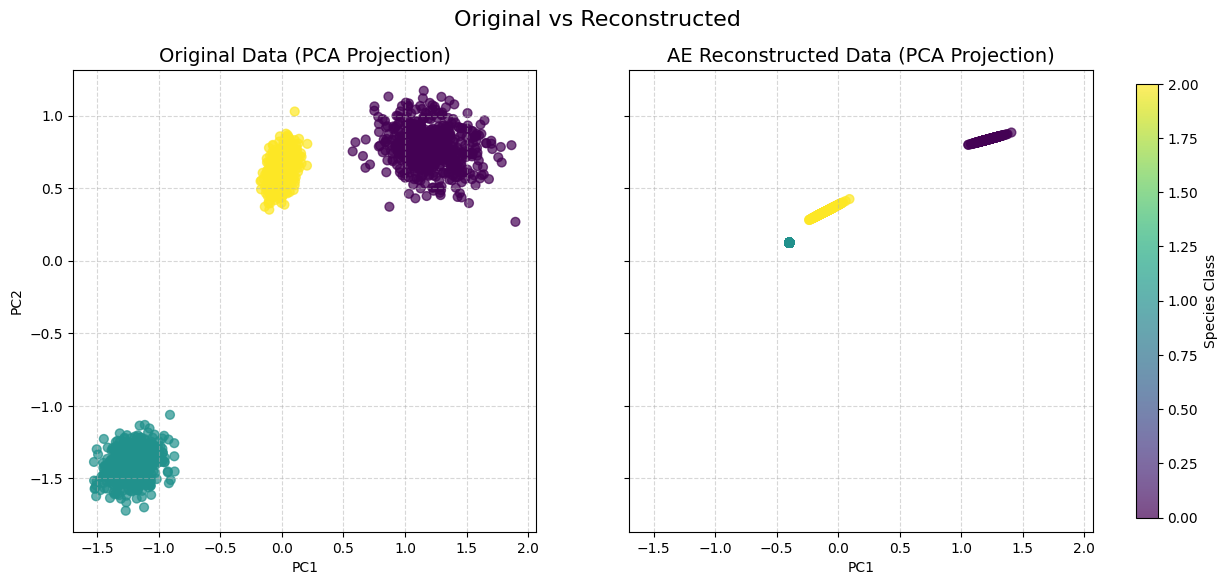

In [31]:
plot_reconstruction_comparison(dae, tensor_x, y, device=device)

In [ ]:
plot_latent_space(dae, tensor_x, y, device=device)

In [ ]:
x_single = torch.tensor([[float('nan'), float('nan'), float('nan'), float('nan')]])
x_single = x_single.to(device)

dae.eval()
with torch.no_grad():
    x_hat, z = dae(x_single)
    direct_z = dae.encoder(x_single)

print(x_hat)
print(z)
print(direct_z)

# DEC

In [26]:
dec = DEC(
    autoencoder=ae,
    num_clusters=len(classes),
    latent_dim=2,
    alpha=10,
).to(device)

dec_optimizer = optim.SGD(dec.parameters(), lr=0.01, momentum=0.9)
dec_loss_fn = KLDivLoss(reduction='batchmean')

In [27]:
dec_losses = train_dec(
    model=dec,
    train_loader=loader,
    optimizer=dec_optimizer,
    loss_fn=dec_loss_fn,
    tensor_x=tensor_x,
    epochs=100,
    device=device
)

Epoch 10/100: average loss = 0.0064
Epoch 20/100: average loss = 0.0043
Epoch 30/100: average loss = 0.0031
Epoch 40/100: average loss = 0.0024
Epoch 50/100: average loss = 0.0021
Epoch 60/100: average loss = 0.0019
Epoch 70/100: average loss = 0.0017
Epoch 80/100: average loss = 0.0015
Epoch 90/100: average loss = 0.0013
Epoch 100/100: average loss = 0.0011


Final Results | Accuracy: 1.0000 | ARI: 1.0000 | NMI: 1.0000


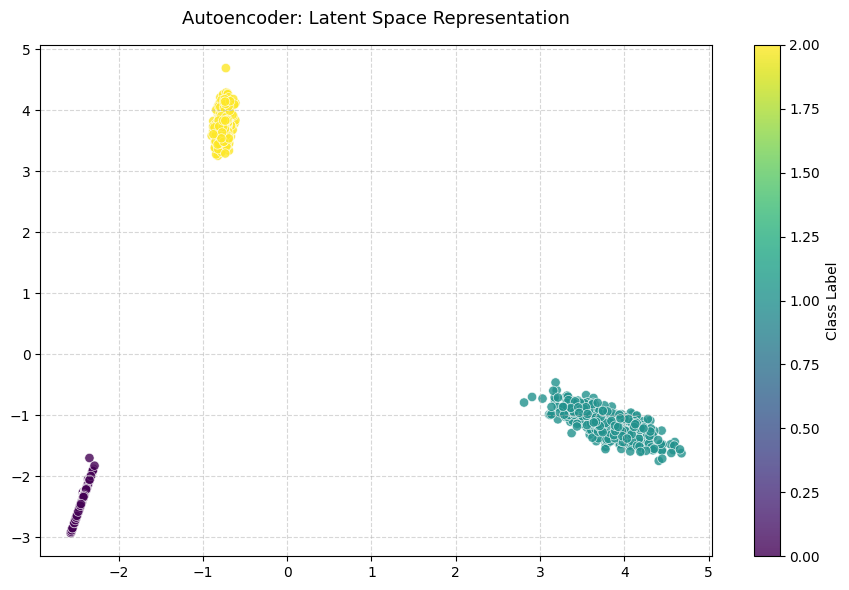

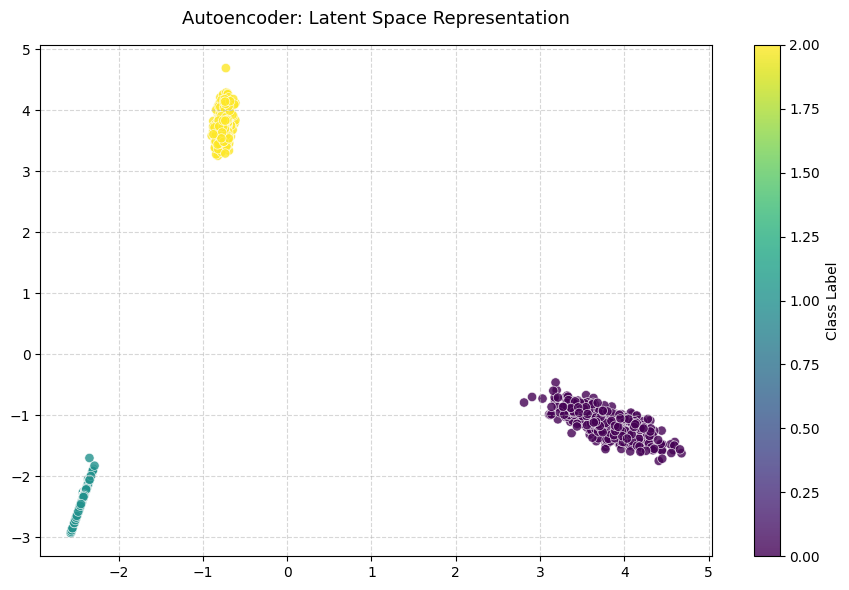

In [28]:
dec.eval()
with torch.no_grad():
    q, z = dec(tensor_x)
    y_pred = torch.argmax(q, dim=1).cpu().numpy()

# Calculate Accuracy
acc = clustering_accuracy(y_true, y_pred)
ari = adjusted_rand_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred)

print(f"Final Results | Accuracy: {acc:.4f} | ARI: {ari:.4f} | NMI: {nmi:.4f}")
plot_latent_space(dec, tensor_x, y_pred, device=device)
plot_latent_space(dec, tensor_x, y, device=device)
